In [1]:
import numpy as np
import scipy
import pandas as pd
import thinkbayes

import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("showcases.2011.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df1 = df.copy()

df = pd.read_csv("showcases.2012.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df2 = df.copy()

df3 = pd.concat([df1, df2], axis=0, ignore_index=True)

df3.head()

Unnamed: 0,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0


In [3]:
showcase1 = df3["Showcase 1"].dropna().values
showcase2 = df3["Showcase 2"].dropna().values

diff1 = df3["Difference 1"].to_numpy()
diff2 = df3["Difference 2"].to_numpy()

bid1 = df3["Bid 1"].dropna().values
bid2 = df3["Bid 2"].dropna().values

In [4]:
class Player(object):
    """Represents a player on The Price is Right."""

    n = 101
    price_xs = np.linspace(0, 75000, n)

    def __init__(self, prices, bids, diffs):
        """Construct the Player.
        Prices: sequence of prices
        bids: sequence of bids
        diffs: sequence of underness (negative means over)
        """

        self.pdf_price = thinkbayes.EstimatedPdf(prices)
        self.pdf_diff = thinkbayes.MakeCdfFromList(diffs)

        mu = 0
        sigma = np.std(diffs)
        self.pdf_error = thinkbayes.GaussianPdf(mu, sigma)

        self.pdf_error_kde = thinkbayes.EstimatedPdf(diffs)

    def ErrorDensity(self, error):
        """Density of the given error in the distribution of error.
        error: how much the bid in under the actual price
        """

        return self.pdf_error.Density(error)

    def PmfPrice(self):
        """Return a new pmf of prices.
        
        A discrete version of the estimated Pdf.
        """

        return self.pdf_price.MakePmf(self.price_xs)

    def CdfDiff(self):
        """Return a reference to the Cdf of differences (underness)."""

        return self.pdf_diff

    def ErrorDensityGauss(self, error):
        """Density of the given error in the distribution of error.
        
        error: how much the bid is under the actual price
        """
        return self.pdf_error_gauss.Density(error)

    def ErrorDensityKDE(self, error):
        return self.pdf_error_kde.Density(error)

    def MakeBeliefs(self, guess):
        """Makes a posterior distribution based on estimated price.
        Sets attributes prior and posterior.
        guess: what the player thinks the showcase is worth
        """

        pmf = self.PmfPrice()
        self.prior = Price(pmf, self, name='prior')
        self.posterior = self.prior.Copy(name='posterior')
        self.posterior.Update(guess)


In [5]:
class Price(thinkbayes.Suite):
    """Represents hypotheses about the price of a showcase."""

    def __init__(self, pmf, player, name=""):
        """Constructs the suite.
        
        pmf: prior distribution of price
        player: player object
        name: string
        """

        thinkbayes.Suite.__init__(self, pmf, name=name)
        self.player = player

    def Likelihood(self, data, hypo):
        """Computes the likelihood of the data under the hypothesis.
        
        hypo: actual price
        data: the contestant's guess
        """

        price = hypo
        guess = data

        error = price - guess
        like = self.player.ErrorDensity(error)

        return like


In [6]:
player1 = Player(showcase1, bid1, diff1)
player2 = Player(showcase2, bid2, diff2)

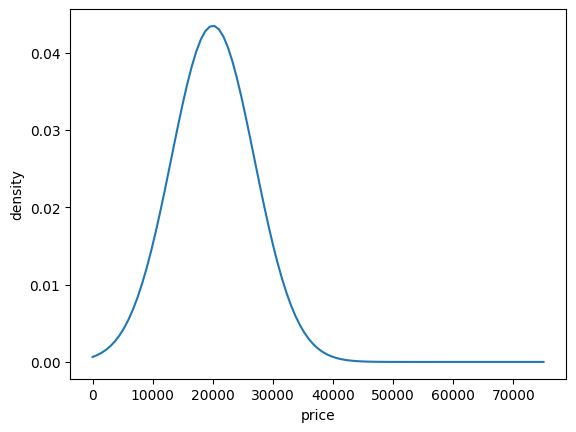

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(0, 75000, 101)

mu = 20000
sigma = np.std(diff1)

y = norm.pdf(x, mu, sigma)
y = y/y.sum()

plt.plot(x, y)
plt.xlabel("price")
plt.ylabel("density")
plt.show()

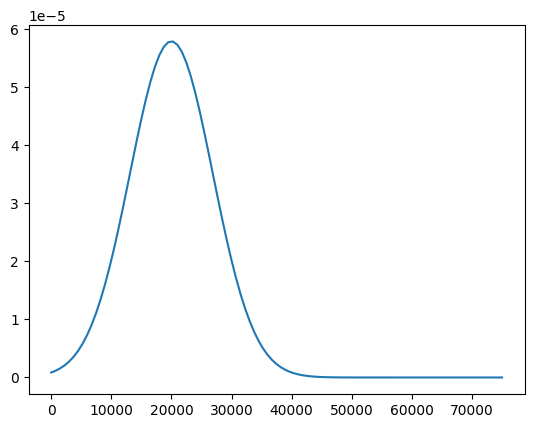

In [8]:
mu = 0
sigma = np.std(diff1)

pdf_error1 = thinkbayes.GaussianPdf(mu,sigma)

guess = 20000

xs = np.linspace(0,75000,101)
error = xs - guess
ys = pdf_error1.Density(error)

plt.plot(xs, ys)

In [9]:
pmf = {20000: 1.0}
price1 = Price(pmf, player1)


guess = 20000
price_xs = np.linspace(0, 75000, 101)


likes = []

for price in price_xs:
    likes.append(price1.Likelihood(guess, price))

likes = np.array(likes)
likes = likes/sum(likes)

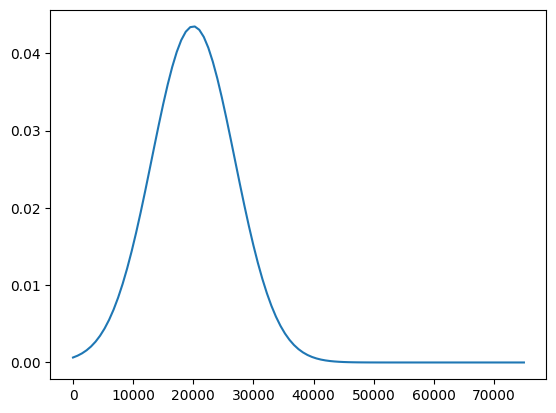

In [10]:
plt.plot(price_xs,likes)